In [7]:
## Load CPDB pairs and the recalculate TM scores using min
import numpy as np
import pandas as pd

fp = '/home/ubuntu/plmCP/CPDB/tm_scores_cpdb_calculated_FIXED_pdbs.txt'

df = pd.read_csv(fp, sep='\t')

In [8]:
len(df)

4169

In [10]:
import pandas as pd
import os
from tqdm import tqdm
import torch
from multiprocessing import Pool, cpu_count
import progres as pg

cirpin_model_fp = "/home/ubuntu/progres-main/scripts/training/CIRPIN_model/model_5k_cp_epoch301.pt"
progres_model_fp = "/home/ubuntu/miniforge3/envs/prog/lib/python3.9/site-packages/progres/trained_models/v_0_2_0/trained_model.pt"

# Load models
cirpin_model = pg.load_trained_model(trained_model=cirpin_model_fp)
progres_model = pg.load_trained_model(trained_model=progres_model_fp)

# Move models to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Base path for PDB files
pdb_base_path = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2'

def convert_pdb_name(pdb):
    """Convert PDB names from '1fp3A' to '1FP3_A'"""
    pdb_code = pdb[:4].upper()
    chain = pdb[4]
    return f'{pdb_code}_{chain}'

def get_pdb_filepath(pdb_name):
    """Convert PDB name and return full filepath"""
    converted_name = convert_pdb_name(pdb_name)
    return os.path.join(pdb_base_path, f'{converted_name}.pdb')

# Cache embeddings to avoid recomputing
embedding_cache = {}

def get_embedding(pdb_path, model, model_name):
    """Get embedding with caching"""
    cache_key = (pdb_path, model_name)
    if cache_key not in embedding_cache:
        embedding_cache[cache_key] = pg.embed_structure(querystructure=pdb_path, model=model)
    return embedding_cache[cache_key]

def calculate_scores(protein1, protein2, progres_model, cirpin_model):
    """Calculate both Progres and CIRPIN scores for a protein pair"""
    # Get filepaths
    p1_path = get_pdb_filepath(protein1)
    p2_path = get_pdb_filepath(protein2)

    # Check if files exist
    if not os.path.exists(p1_path) or not os.path.exists(p2_path):
        print(f'PDB not found')
        return None, None
    
    try:
        # Calculate Progres score using cached embeddings
        p1_progres = get_embedding(p1_path, progres_model, 'progres')
        p2_progres = get_embedding(p2_path, progres_model, 'progres')
        progres_score = pg.embedding_similarity(p1_progres, p2_progres)
        
        # Calculate CIRPIN score using cached embeddings
        p1_cirpin = get_embedding(p1_path, cirpin_model, 'cirpin')
        p2_cirpin = get_embedding(p2_path, cirpin_model, 'cirpin')
        cirpin_score = pg.embedding_similarity(p1_cirpin, p2_cirpin)
        # Convert to float immediately
        progres_score = progres_score.item() if hasattr(progres_score, 'item') else progres_score
        cirpin_score = cirpin_score.item() if hasattr(cirpin_score, 'item') else cirpin_score
        
        return progres_score, cirpin_score
    
    except Exception as e:
        return None, None

# Calculate scores with optimizations
print("Calculating Progres and CIRPIN scores...")

# SIMPLE SINGLE-THREADED VERSION (safer, easier to debug)
progres_scores = []
cirpin_scores = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    progres_score, cirpin_score = calculate_scores(
        row['Protein1'], 
        row['Protein2'], 
        progres_model, 
        cirpin_model
    )
    progres_scores.append(progres_score)
    cirpin_scores.append(cirpin_score)

# Add scores to dataframe (already converted to floats)
df['progres_score'] = progres_scores
df['cirpin_score'] = cirpin_scores

# Display results
print("\nResults:")
print(df.head())

# Check for any failed calculations
failed_rows = df[df['progres_score'].isna()]
if len(failed_rows) > 0:
    print(f"\nWarning: {len(failed_rows)} rows failed to calculate scores")

print(f"\nCache size: {len(embedding_cache)} embeddings cached")

/home/ubuntu/miniforge3/envs/prog/lib/python3.9/site-packages/progres/trained_models/v_0_2_0/trained_model.pt
Using model model_5k_cp_epoch301.pt
Using model trained_model.pt
Using device: cuda
Calculating Progres and CIRPIN scores...


100%|██████████| 4169/4169 [02:20<00:00, 29.62it/s] 


Results:
  Protein1 Protein2  tmscore  tmscore-CP  tm_score_calculated  \
0    1fp3A    1vd5A  0.67760     0.67760              0.67760   
1    1fp3A    1wu4A  0.67768     0.67887              0.67768   
2    1fp3A    2drqA  0.67558     0.67691              0.67558   
3    1fp3A    1wu6A  0.67434     0.67558              0.67434   
4    1fp3A    1hzfA  0.54695     0.55763              0.54695   

   tm_score_cp_calculated  progres_score  cirpin_score  
0                 0.67760       0.939401      0.983705  
1                 0.67887       0.971649      0.990784  
2                 0.67691       0.976586      0.990878  
3                 0.67558       0.974675      0.990933  
4                 0.55763       0.911674      0.948243  


Cache size: 4457 embeddings cached


In [76]:
df.head()

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243


In [65]:
df.to_csv('/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/', index=False)

In [3]:
df = pd.read_csv("cpdb_tm_scores_progres_cirpin_scores.csv")

In [5]:
df.rename(
    columns={
        "tmscore": "tmscore_max",
        "tmscore-CP": "tmscore-CP_max"
    },
    inplace=True
)

In [140]:
df_filtered_un = df[
    (df['Protein1'] == '1un2A') |
    (df['Protein2'] == '1un2A')
]

In [144]:
df_filtered_un1 = df_filtered_un.drop(columns=['tmscore', 'tmscore-CP'])
df_filtered_un1

,Protein1,Protein2,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,difference
4148,1a23A,1un2A,0.45417,0.81368,0.984426,0.988718,0.35951
4149,1ac1A,1un2A,0.50342,0.93870,0.984774,0.991518,0.43528
4150,1acvA,1un2A,0.50519,0.94177,0.983860,0.991701,0.43658
4151,1bedA,1un2A,0.46898,0.86295,0.979549,0.990983,0.39397
4152,1fvjA,1un2A,0.50742,0.94509,0.984608,0.990853,0.43767
4153,1r4wA,1un2A,0.30433,0.56110,0.978588,0.976646,0.25677
4154,1ti1A,1un2A,0.48785,0.93896,0.991267,0.995208,0.45111
4155,1un2A,1bq7A,0.51353,0.96431,0.989165,0.995577,0.45078
4156,1un2A,2b3sA,0.47593,0.90986,0.985751,0.993427,0.43393
4159,1yzxA,1un2A,0.30365,0.56550,0.976762,0.971317,0.26185


In [146]:

cols = ['tm_score_calculated', 'tm_score_cp_calculated', 
        'progres_score', 'cirpin_score',
       'difference']

df_filtered_un1[cols] = df_filtered_un1[cols].apply(
    lambda s: np.round(
        s,
        3 - np.floor(np.log10(np.abs(s))).astype(int) - 1
    )
)

TypeError: cannot convert the series to <class 'int'>

In [145]:
df_filtered_un1.to_csv('engineered_cp.csv')

In [135]:
df_filtered_tm = df[
    (df['tm_score_cp_calculated'] > 0.5) &
    ((df['tm_score_cp_calculated'] - df['tm_score_calculated']) > 0.35)
]



,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,difference
871,1ajkA,1u0aA,0.56902,0.94342,0.56382,0.93477,0.986758,0.997516,0.37095
874,1ajkA,1byhA,0.56919,0.93909,0.56400,0.93050,0.986416,0.998572,0.36650
924,1ajoA,1umzA,0.31726,0.77771,0.26941,0.62954,0.984748,0.978616,0.36013
951,1apnA,2fmdA,0.47348,0.93748,0.45757,0.90610,0.952851,0.996608,0.44853
952,1apnA,1q8oA,0.47129,0.91694,0.44276,0.86146,0.955296,0.993365,0.41870
...,...,...,...,...,...,...,...,...,...
4152,1fvjA,1un2A,0.50742,0.94509,0.50742,0.94509,0.984608,0.990853,0.43767
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,0.45111
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,0.45078
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,0.43393


In [138]:
len(set(list(pd.concat(df_filtered_tm['Protein1'],df_filtered_tm['Protein2'])))


SyntaxError: unexpected EOF while parsing (3018717421.py, line 1)

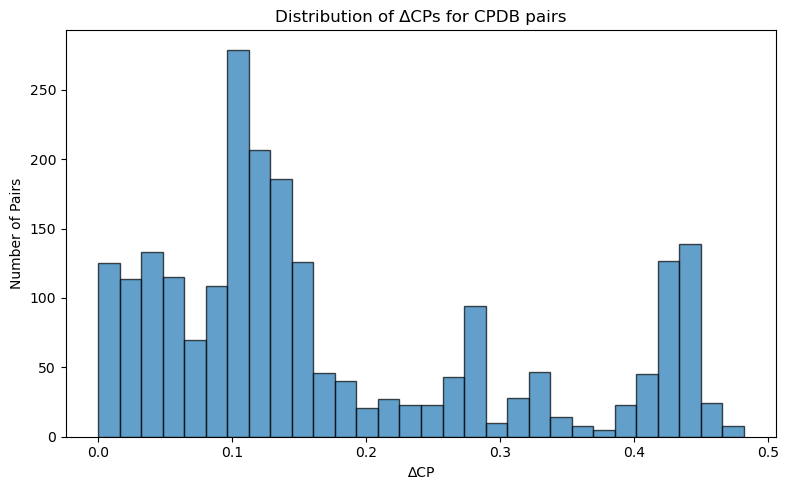

In [134]:
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df_filtered_tm["difference"], bins=30, edgecolor="black", alpha=0.7)

plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")

plt.tight_layout()
plt.show()

In [121]:
df_filtered_tm['prog_cirpin_diff']=(df['cirpin_score'] - df['progres_score'])

/tmp/ipykernel_3538733/1330484165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_tm['prog_cirpin_diff']=(df['cirpin_score'] - df['progres_score'])


In [110]:
import pandas as pd
import subprocess
import os

# Base path for PDB files
pdb_base_path = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2'
destination = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/combined_afdb_scope_cpdb_fixed_tm_min'

def convert_pdb_name(pdb):
    """Convert PDB names from '1fp3A' to '1FP3_A'"""
    pdb_code = pdb[:4].upper()
    chain = pdb[4]
    return f'{pdb_code}_{chain}'

# Get all unique protein names
all_names_cpdb = pd.concat([df['Protein1'], df['Protein2']])
all_names_cpdb_unique = all_names_cpdb.unique()
print(f"Number of unique proteins: {len(all_names_cpdb_unique)}")

# Copy files
for pdb_name in all_names_cpdb_unique:
    converted_name = convert_pdb_name(pdb_name)
    source_path = os.path.join(pdb_base_path, f'{converted_name}.pdb')
    destination_path = os.path.join(destination, f'{converted_name}.pdb')
    
    try:
        if os.path.exists(source_path):
            subprocess.run(['cp', source_path, destination_path], check=True)
            print(f"Copied: {converted_name}.pdb")
        else:
            print(f"File not found: {source_path}")
    except Exception as e:
        print(f"Error copying {converted_name}: {e}")

print("File copying complete!")

Number of unique proteins: 2238
Copied: 1FP3_A.pdb
Copied: 1NC5_A.pdb
Copied: 1V5C_A.pdb
Copied: 1VD5_A.pdb
Copied: 1WZZ_A.pdb
Copied: 2AHF_A.pdb
Copied: 2GH4_A.pdb
Copied: 2SQC_A.pdb
Copied: 1A22_A.pdb
Copied: 1A7D_A.pdb
Copied: 1A7M_A.pdb
Copied: 1AEW_A.pdb
Copied: 1ALU_A.pdb
Copied: 1AU1_A.pdb
Copied: 1AX8_A.pdb
Copied: 1AXI_A.pdb
Copied: 1B5L_A.pdb
Copied: 1BBH_A.pdb
Copied: 1BCF_A.pdb
Copied: 1BG7_A.pdb
Copied: 1BGC_A.pdb
Copied: 1BGD_A.pdb
Copied: 1BUY_A.pdb
Copied: 1CD9_A.pdb
Copied: 1CNT_1.pdb
Copied: 1CSM_A.pdb
Copied: 1DDN_A.pdb
Copied: 1DPS_A.pdb
Copied: 1EA8_A.pdb
Copied: 1EER_A.pdb
Copied: 1EMR_A.pdb
Copied: 1EUM_A.pdb
Copied: 1EVS_A.pdb
Copied: 1F1M_A.pdb
Copied: 1F30_A.pdb
Copied: 1F6F_A.pdb
Copied: 1FHA_A.pdb
Copied: 1FXK_A.pdb
Copied: 1FXK_C.pdb
Copied: 1GNC_A.pdb
Copied: 1GWG_A.pdb
Copied: 1H96_A.pdb
Copied: 1HUW_A.pdb
Copied: 1HWG_A.pdb
Copied: 1I1R_B.pdb
Copied: 1IL6_A.pdb
Copied: 1JGC_A.pdb
Copied: 1JI5_A.pdb
Copied: 1JMW_A.pdb
Copied: 1JRE_A.pdb
Copied: 1K33_A.pdb

### Copy CPDB verified CPs (according to CP cutoff)

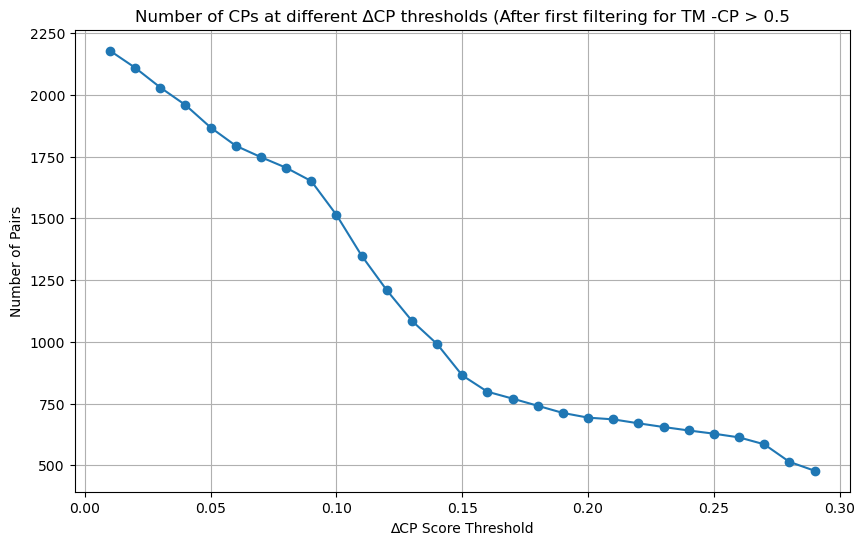

In [128]:
import matplotlib.pyplot as plt
import numpy as np

score_diff_lens = {}
for i in np.arange(0.01, 0.3, 0.01):  # 0.01 to 0.1 in 0.01 increments
    df_filtered_tm = df[
        (df['tm_score_cp_calculated'] > 0.5) &
        (df['tm_score_cp_calculated'] - df['tm_score_calculated'] > i)
    ]
    score_diff_lens[i] = len(df_filtered_tm)

# Plot dictionary
plt.figure(figsize=(10, 6))
plt.plot(list(score_diff_lens.keys()), list(score_diff_lens.values()), marker='o')
plt.xlabel('∆CP Score Threshold')
plt.ylabel('Number of Pairs')
plt.title('Number of CPs at different ∆CP thresholds (After first filtering for TM -CP > 0.5')
plt.grid(True)
plt.show()

In [129]:
df_filtered_tm

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,difference
871,1ajkA,1u0aA,0.56902,0.94342,0.56382,0.93477,0.986758,0.997516,0.37095
874,1ajkA,1byhA,0.56919,0.93909,0.56400,0.93050,0.986416,0.998572,0.36650
919,1ajoA,1cpnA,0.64425,0.96345,0.64425,0.96345,0.981037,0.997640,0.31920
924,1ajoA,1umzA,0.31726,0.77771,0.26941,0.62954,0.984748,0.978616,0.36013
951,1apnA,2fmdA,0.47348,0.93748,0.45757,0.90610,0.952851,0.996608,0.44853
...,...,...,...,...,...,...,...,...,...
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,0.45111
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,0.45078
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,0.43393
4160,2b6mA,1un2A,0.50505,0.95804,0.50505,0.95804,0.986281,0.993042,0.45299


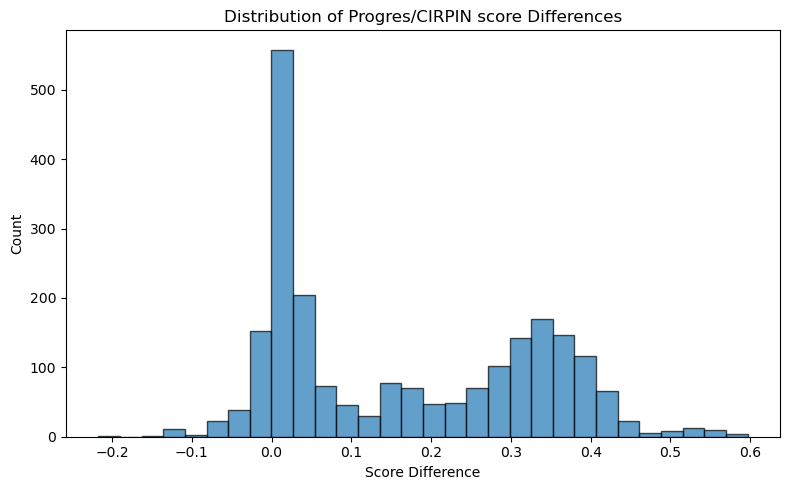

In [123]:
df_filtered_tm
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df_filtered_tm["prog_cirpin_diff"], bins=30, edgecolor="black", alpha=0.7)

plt.xlabel("Score Difference")
plt.ylabel("Count")
plt.title("Distribution of Progres/CIRPIN score Differences")

plt.tight_layout()
plt.show()

In [73]:
all_names_cpdb = pd.concat([df_filtered_tm['Protein1'], df_filtered_tm['Protein2']])

all_names_cpdb_unique = all_names_cpdb.unique()

In [75]:
len(all_names_cpdb_unique)

103

In [72]:
df_filtered_tm

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score
53,1a22A,1umnA,0.42445,0.54107,0.42445,0.54107,0.598245,0.951909
55,1a22A,2clbA,0.45272,0.53663,0.45272,0.53663,0.599446,0.945426
66,1aluA,2clbA,0.48948,0.64593,0.4703,0.61984,0.585942,0.961932
67,1aluA,1n1qA,0.48005,0.62326,0.48005,0.62326,0.599696,0.947684
68,1aluA,2ib0A,0.49646,0.65294,0.49646,0.65294,0.593595,0.990889
...,...,...,...,...,...,...,...,...
3868,2d80A,1jjiA,0.34743,0.59022,0.34743,0.59022,0.581105,0.968988
3871,2d81A,1jjfA,0.34888,0.60625,0.34888,0.60625,0.573846,0.978253
3874,2d81A,1jjiA,0.32765,0.59243,0.32765,0.59243,0.585404,0.969876
3875,2d81A,1auoA,0.34392,0.57634,0.34392,0.57634,0.563799,0.920603


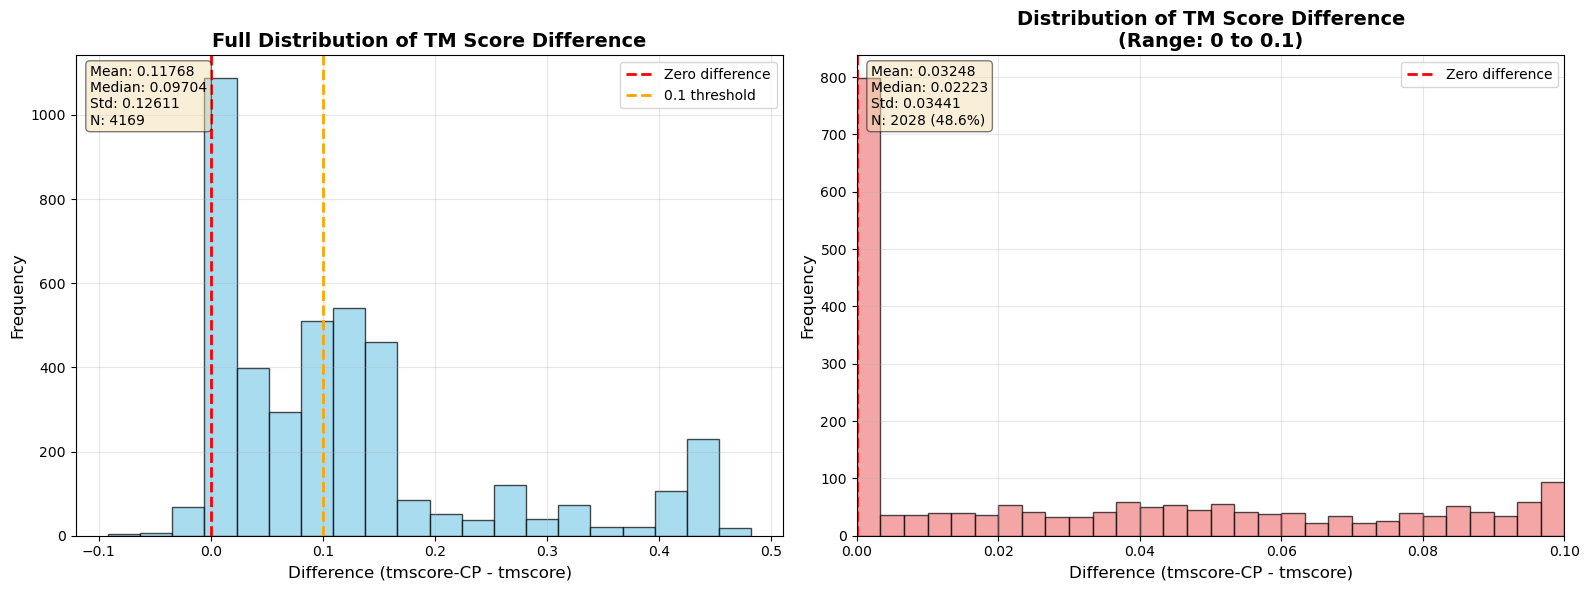

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate the difference
df['difference'] = df['tm_score_cp_calculated'] - df['tm_score_calculated']

# Filter data for differences between 0 and 0.1
df2 = df[(df['difference'] >= 0) & (df['difference'] <= 0.1)]

# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full distribution
ax1.hist(df['difference'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax1.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='0.1 threshold')
ax1.set_xlabel('Difference (tmscore-CP - tmscore)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Full Distribution of TM Score Difference', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add statistics for full distribution
mean_diff = df['difference'].mean()
median_diff = df['difference'].median()
std_diff = df['difference'].std()
textstr1 = f'Mean: {mean_diff:.5f}\nMedian: {median_diff:.5f}\nStd: {std_diff:.5f}\nN: {len(df)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.02, 0.98, textstr1, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Plot 2: Filtered distribution (0 to 0.1)
ax2.hist(df2['difference'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax2.set_xlabel('Difference (tmscore-CP - tmscore)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of TM Score Difference\n(Range: 0 to 0.1)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 0.1)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add statistics for filtered distribution
mean_filt = df2['difference'].mean()
median_filt = df2['difference'].median()
std_filt = df2['difference'].std()
pct_in_range = (len(df2) / len(df)) * 100
textstr2 = f'Mean: {mean_filt:.5f}\nMedian: {median_filt:.5f}\nStd: {std_filt:.5f}\nN: {len(df2)} ({pct_in_range:.1f}%)'
ax2.text(0.02, 0.98, textstr2, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

In [37]:
all_names_cpdb = pd.concat([df['Protein1'], df['Protein2']])

all_names_cpdb_unique = all_names_cpdb.unique()
print(f'Sample of unique cpdb domains: {all_names_cpdb_unique[0:5]}, total: {len(all_names_cpdb_unique)}')

Sample of unique cpdb domains: ['1fp3A' '1nc5A' '1v5cA' '1vd5A' '1wzzA'], total: 2207


In [38]:
len(all_names_cpdb_unique)

2207

In [39]:
df_tm_cp_above05 = df[df['tm_score_cp_calculated'] > 0.5]

df_tm_cp_above05_diff_greater_than_0 = df_tm_cp_above05[(df_tm_cp_above05['tm_score_cp_calculated']-df_tm_cp_above05['tm_score_calculated']) > 0]

print(f'After filtering based on TM CP difference {len(df_tm_cp_above05_diff_greater_than_0)}')
all_names = pd.concat([df_tm_cp_above05_diff_greater_than_0['Protein1'], df_tm_cp_above05_diff_greater_than_0['Protein2']])
all_names_unique = all_names.unique()
print(f'Total unique: {len(all_names_unique)}')

After filtering based on TM CP difference 2321
Total unique: 999


### Calculate Progres/CIRPIN scores for all these pairs

In [1]:
import progres as pg
import torch

/home/ubuntu/miniforge3/envs/prog/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ubuntu/miniforge3/envs/prog/lib/python3.9/site-packages/progres/trained_models/v_0_2_0/trained_model.pt


In [41]:
import pandas as pd
import os
from tqdm import tqdm

cirpin_model_fp = "/home/ubuntu/progres-main/scripts/training/CIRPIN_model/model_5k_cp_epoch301.pt"
progres_model_fp = "/home/ubuntu/miniforge3/envs/prog/lib/python3.9/site-packages/progres/trained_models/v_0_2_0/trained_model.pt"

# Load models
cirpin_model = pg.load_trained_model(trained_model=cirpin_model_fp)
progres_model = pg.load_trained_model(trained_model=progres_model_fp)

# Base path for PDB files
pdb_base_path = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2'

def convert_pdb_name(pdb):
    """Convert PDB names from '1fp3A' to '1FP3_A'"""
    pdb_code = pdb[:4].upper()
    chain = pdb[4]
    return f'{pdb_code}_{chain}'

def get_pdb_filepath(pdb_name):
    """Convert PDB name and return full filepath"""
    converted_name = convert_pdb_name(pdb_name)
    return os.path.join(pdb_base_path, f'{converted_name}.pdb')

def calculate_scores(protein1, protein2, progres_model, cirpin_model):
    """Calculate both Progres and CIRPIN scores for a protein pair"""
    # Get filepaths
    p1_path = get_pdb_filepath(protein1)
    p2_path = get_pdb_filepath(protein2)
    
    # Check if files exist
    if not os.path.exists(p1_path):
        print(f"Warning: {p1_path} not found")
        return None, None
    if not os.path.exists(p2_path):
        print(f"Warning: {p2_path} not found")
        return None, None
    
    try:
        # Calculate Progres score
        p1_progres = pg.embed_structure(querystructure=p1_path, model=progres_model)
        p2_progres = pg.embed_structure(querystructure=p2_path, model=progres_model)
        progres_score = pg.embedding_similarity(p1_progres, p2_progres)
        
        # Calculate CIRPIN score
        p1_cirpin = pg.embed_structure(querystructure=p1_path, model=cirpin_model)
        p2_cirpin = pg.embed_structure(querystructure=p2_path, model=cirpin_model)
        cirpin_score = pg.embedding_similarity(p1_cirpin, p2_cirpin)
        
        return progres_score, cirpin_score
    
    except Exception as e:
        print(f"Error processing {protein1} - {protein2}: {str(e)}")
        return None, None

# Initialize lists to store scores
progres_scores = []
cirpin_scores = []

# Calculate scores for each row
print("Calculating Progres and CIRPIN scores...")
for idx, row in tqdm(df_tm_cp_above05_diff_greater_than_0.iterrows(), 
                     total=len(df_tm_cp_above05_diff_greater_than_0)):
    progres_score, cirpin_score = calculate_scores(
        row['Protein1'], 
        row['Protein2'], 
        progres_model, 
        cirpin_model
    )
    progres_scores.append(progres_score)
    cirpin_scores.append(cirpin_score)

# Add scores to dataframe
df_tm_cp_above05_diff_greater_than_0['progres_score'] = progres_scores
df_tm_cp_above05_diff_greater_than_0['cirpin_score'] = cirpin_scores

# Display results
print("\nResults:")
print(df_tm_cp_above05_diff_greater_than_0.head())

# Check for any failed calculations
failed_rows = df_tm_cp_above05_diff_greater_than_0[
    df_tm_cp_above05_diff_greater_than_0['progres_score'].isna()
]
if len(failed_rows) > 0:
    print(f"\nWarning: {len(failed_rows)} rows failed to calculate scores")

Using model model_5k_cp_epoch301.pt
Using model trained_model.pt
Calculating Progres and CIRPIN scores...


100%|██████████| 2321/2321 [04:42<00:00,  8.22it/s]


Results:
  Protein1 Protein2  tmscore  tmscore-CP tm_score_calculated  \
1    1fp3A    1wu4A  0.67768     0.67887             0.67768   
2    1fp3A    2drqA  0.67558     0.67691             0.67558   
3    1fp3A    1wu6A  0.67434     0.67558             0.67434   
4    1fp3A    1hzfA  0.54695     0.55763             0.54695   
5    1fp3A    1ks8A  0.63233     0.69125             0.59385   

  tm_score_cp_calculated   progres_score    cirpin_score  
1                0.67887  tensor(0.9716)  tensor(0.9908)  
2                0.67691  tensor(0.9766)  tensor(0.9909)  
3                0.67558  tensor(0.9747)  tensor(0.9909)  
4                0.55763  tensor(0.9117)  tensor(0.9482)  
5                0.64707  tensor(0.9587)  tensor(0.9824)  



/tmp/ipykernel_3538733/1530497838.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tm_cp_above05_diff_greater_than_0['progres_score'] = progres_scores
/tmp/ipykernel_3538733/1530497838.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tm_cp_above05_diff_greater_than_0['cirpin_score'] = cirpin_scores


/tmp/ipykernel_3538733/3227058583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tm_cp_above05_diff_greater_than_0['progres_score'] = df_tm_cp_above05_diff_greater_than_0['progres_score'].apply(
/tmp/ipykernel_3538733/3227058583.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tm_cp_above05_diff_greater_than_0['cirpin_score'] = df_tm_cp_above05_diff_greater_than_0['cirpin_score'].apply(


In [46]:
df_filtered = df_tm_cp_above05_diff_greater_than_0[
    (df_tm_cp_above05_diff_greater_than_0['progres_score'] < 0.6) & 
    (df_tm_cp_above05_diff_greater_than_0['cirpin_score'] > 0.9)
]

In [47]:
df_filtered

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score
53,1a22A,1umnA,0.42445,0.54107,0.42445,0.54107,0.598245,0.951909
55,1a22A,2clbA,0.45272,0.53663,0.45272,0.53663,0.599446,0.945426
66,1aluA,2clbA,0.48948,0.64593,0.4703,0.61984,0.585942,0.961932
67,1aluA,1n1qA,0.48005,0.62326,0.48005,0.62326,0.599696,0.947684
68,1aluA,2ib0A,0.49646,0.65294,0.49646,0.65294,0.593595,0.990889
...,...,...,...,...,...,...,...,...
3868,2d80A,1jjiA,0.34743,0.59022,0.34743,0.59022,0.581105,0.968988
3871,2d81A,1jjfA,0.34888,0.60625,0.34888,0.60625,0.573846,0.978253
3874,2d81A,1jjiA,0.32765,0.59243,0.32765,0.59243,0.585404,0.969876
3875,2d81A,1auoA,0.34392,0.57634,0.34392,0.57634,0.563799,0.920603


In [ ]:
emb1 = pg.embed_structure('/home/ubuntu/pdbscratch/d3cnaa_.pdb')
emb2 = pg.embed_structure('/home/ubuntu/pdbscratch/d2pela_.pdb')


In [35]:
df_tm_cp_above05_diff_greater_than_0[df_tm_cp_above05_diff_greater_than_0['Protein2'] == '2drqA']

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691
6,1nc5A,2drqA,0.65850,0.66306,0.63718,0.64225


In [26]:
def convert_pdb_name(pdb):
    """Convert PDB names from '1fp3A' to '1FP3_A'"""
    pdb_code = pdb[:4].upper()
    chain = pdb[4]
    return f'{pdb_code}_{chain}'

In [27]:
all_names_unique_pdb = np.array([convert_pdb_name(x) for x in all_names_unique])


In [28]:
all_names_unique_pdb

array(['1FP3_A', '1NC5_A', '1V5C_A', '1VD5_A', '1WZZ_A', '2AHF_A',
       '2GH4_A', '1A22_A', '1AEW_A', '1ALU_A', '1AU1_A', '1AX8_A',
       '1AXI_A', '1B5L_A', '1BBH_A', '1BCF_A', '1BG7_A', '1BGC_A',
       '1BGD_A', '1BUY_A', '1CD9_A', '1CNT_1', '1CSM_A', '1DDN_A',
       '1DPS_A', '1EA8_A', '1EER_A', '1EMR_A', '1EUM_A', '1EVS_A',
       '1F1M_A', '1F30_A', '1F6F_A', '1FHA_A', '1FXK_C', '1GWG_A',
       '1H96_A', '1HWG_A', '1I1R_B', '1IL6_A', '1JGC_A', '1JI5_A',
       '1JMW_A', '1JRE_A', '1K40_A', '1L3P_A', '1LIH_A', '1LKI_A',
       '1MFR_A', '1NF4_A', '1O9R_A', '1P9M_B', '1PVH_B', '1QGH_A',
       '1QQ3_A', '1R03_A', '1RCC_A', '1RCD_A', '1RCI_A', '1RHG_A',
       '1S3Q_A', '1SOF_A', '1UMN_A', '1UVH_A', '1VLG_A', '1VLS_A',
       '1WU3_I', '1WVT_A', '1YJG_A', '1Z4A_A', '1Z6O_M', '1Z7C_A',
       '1ZUJ_A', '1ZWI_C', '2ASR_A', '2ATK_C', '2BJY_A', '2BK6_A',
       '2BKC_A', '2C2F_A', '2C41_A', '2CF7_A', '2CHI_A', '2CLB_A',
       '2CLU_A', '2CN7_A', '2FFX_J', '2FKZ_A', '2FZF_A', '2G2D

In [32]:
import subprocess
import os

# Define paths
source_folder = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2'
destination_folder = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/combined_afdb_scope_cpdb_tm_min'

# Copy each file
for filename in all_names_unique_pdb:
    filename_pdb = filename + '.pdb'
    source_path = os.path.join(source_folder, filename_pdb)
    destination_path = os.path.join(destination_folder, filename_pdb)
    
    subprocess.run(['cp', source_path, destination_path])